In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
df100 = pd.read_csv("39_001_100pc.csv")
df130 = pd.read_csv("39_001_130pc.csv")

In [11]:
df100.columns

Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'source_id', 'ra', 'dec',
       'parallax', 'pmra', 'pmdec', 'ruwe', 'phot_g_mean_mag', 'bp_rp',
       'radial_velocity', 'ra_error', 'dec_error', 'pmra_error', 'pmdec_error',
       'parallax_error', 'visibility_periods_used', 'phot_bp_mean_mag',
       'phot_rp_mean_mag', 'nu_eff_used_in_astrometry', 'pseudocolour',
       'ecl_lat', 'astrometric_params_solved', 'zp', 'fidelity_v2',
       'parallax_', 'relative_error', 'cell_id', 'distance', 'cluster_id'],
      dtype='str')

In [12]:
# Antes del merge, quédate solo con source_id en uno de los dos
df_merged = pd.merge(df100, df130[['source_id']], on='source_id')

In [13]:
df_merged.columns

Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'source_id', 'ra', 'dec',
       'parallax', 'pmra', 'pmdec', 'ruwe', 'phot_g_mean_mag', 'bp_rp',
       'radial_velocity', 'ra_error', 'dec_error', 'pmra_error', 'pmdec_error',
       'parallax_error', 'visibility_periods_used', 'phot_bp_mean_mag',
       'phot_rp_mean_mag', 'nu_eff_used_in_astrometry', 'pseudocolour',
       'ecl_lat', 'astrometric_params_solved', 'zp', 'fidelity_v2',
       'parallax_', 'relative_error', 'cell_id', 'distance', 'cluster_id'],
      dtype='str')

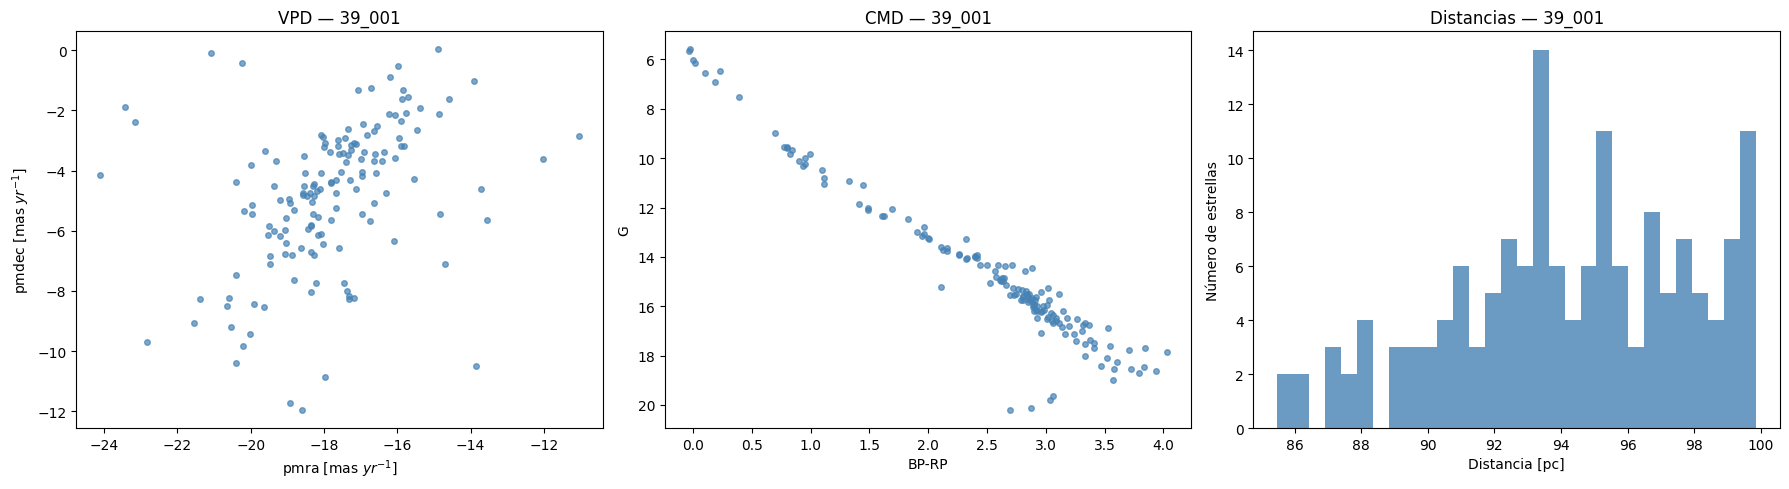

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax_vpd, ax_cmd, ax_hist = axes

# VPD
ax_vpd.plot(df_merged['pmra'], df_merged['pmdec'],
            marker='o', linestyle='None', markersize=4,
            color='steelblue', alpha=0.7)
ax_vpd.set_xlabel("pmra [mas $yr^{-1}$]")
ax_vpd.set_ylabel("pmdec [mas $yr^{-1}$]")
ax_vpd.set_title("VPD — 39_001")

# CMD
ax_cmd.plot(df_merged['phot_bp_mean_mag'] - df_merged['phot_rp_mean_mag'],
            df_merged['phot_g_mean_mag'],
            marker='o', linestyle='None', markersize=4,
            color='steelblue', alpha=0.7)
ax_cmd.set_xlabel("BP-RP")
ax_cmd.set_ylabel("G")
ax_cmd.invert_yaxis()
ax_cmd.set_title("CMD — 39_001")

# Histograma de distancias
ax_hist.hist(df_merged['distance'], bins=30, color='steelblue', alpha=0.8)
ax_hist.set_xlabel("Distancia [pc]")
ax_hist.set_ylabel("Número de estrellas")
ax_hist.set_title("Distancias — 39_001")

plt.tight_layout()
plt.show()

In [15]:
df_merged.shape

(150, 32)